# Shadow Analysis

Computes where tree canopies cast shadows given a sun position derived from a UTC datetime.
Loads existing segmentation maps (`.npy`) and overlays shadow predictions on the orthophoto.

In [21]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.config import AREAS, OUTPUT_DIR, TILE_SIZE_M
from src.data_preprocessing import tiles_for_area
from src.shadow import sun_position, estimate_tree_heights, cast_tree_shadows, save_shadow_overlay
from src.shadow.casting import _pixel_size_m

## Parameters

In [22]:
AREA_KEY = "ovgu_bbox"
TILE_IX, TILE_IY = 0, 0
VEGETATION_MODEL = "tcd_segformer"

# Summer solstice ~1 hour before solar noon (sun is SSE, elevation ~61°)
DATETIME_UTC = dt.datetime(2024, 6, 21, 11, 0, 0, tzinfo=dt.timezone.utc)

## Load segmentation and orthophoto

In [23]:
tiles = tiles_for_area(AREAS[AREA_KEY], TILE_SIZE_M)
tile = next(t for t in tiles if t["ix"] == TILE_IX and t["iy"] == TILE_IY)

stem = f"{AREA_KEY}_tile_{TILE_IX}_{TILE_IY}"
seg_path = OUTPUT_DIR / "segments" / f"{TILE_SIZE_M}m" / f"{stem}_{VEGETATION_MODEL}_seg.npy"
img_path = OUTPUT_DIR / AREA_KEY / f"{TILE_SIZE_M}m" / f"{stem}.png"

seg_map = np.load(seg_path)
img = np.array(Image.open(img_path).convert("RGB"))

print(f"seg_map shape: {seg_map.shape}  dtype: {seg_map.dtype}")
print(f"Class distribution: " + "  ".join(f"{v}={int((seg_map==v).sum())} ({(seg_map==v).mean()*100:.1f}%)" for v in [0,1,2,3]))

seg_map shape: (1200, 1200)  dtype: uint8
Class distribution: 0=529492 (36.8%)  1=232777 (16.2%)  2=438054 (30.4%)  3=239677 (16.6%)


## Sun position

In [24]:
lat = (tile["south"] + tile["north"]) / 2
lon = (tile["west"] + tile["east"]) / 2
azimuth, elevation = sun_position(lat, lon, DATETIME_UTC)
shadow_dir = (azimuth + 180) % 360

print(f"Location: {lat:.4f}°N  {lon:.4f}°E")
print(f"Date/time: {DATETIME_UTC.strftime('%Y-%m-%d %H:%M UTC')}")
print(f"Sun azimuth:  {azimuth:.1f}°  (compass, 0°=N)")
print(f"Sun elevation: {elevation:.1f}°")
print(f"Shadow falls toward: {shadow_dir:.1f}°")

Location: 52.1387°N  11.6417°E
Date/time: 2024-06-21 11:00 UTC
Sun azimuth:  172.7°  (compass, 0°=N)
Sun elevation: 61.2°
Shadow falls toward: 352.7°


## Tree height estimation

In [25]:
pixel_size = _pixel_size_m(tile, seg_map.shape)
labeled, heights = estimate_tree_heights(seg_map == 1, pixel_size)

height_values = [h[0] for h in heights.values()]
print(f"Pixel size: {pixel_size:.3f} m/px")
print(f"Tree clusters: {len(heights)}")
if height_values:
    print(f"Height range: {min(height_values):.1f} – {max(height_values):.1f} m")
    print(f"Median height: {sorted(height_values)[len(height_values)//2]:.1f} m")

Pixel size: 0.208 m/px
Tree clusters: 93
Height range: 5.1 – 32.1 m
Median height: 14.5 m


## Cast shadows

In [26]:
shadow_mask = cast_tree_shadows(seg_map, tile, DATETIME_UTC)
print(f"Shadow pixels: {shadow_mask.sum()} ({shadow_mask.mean()*100:.1f}% of tile)")

Shadow pixels: 169832 (11.8% of tile)


## Visualise shadow overlay

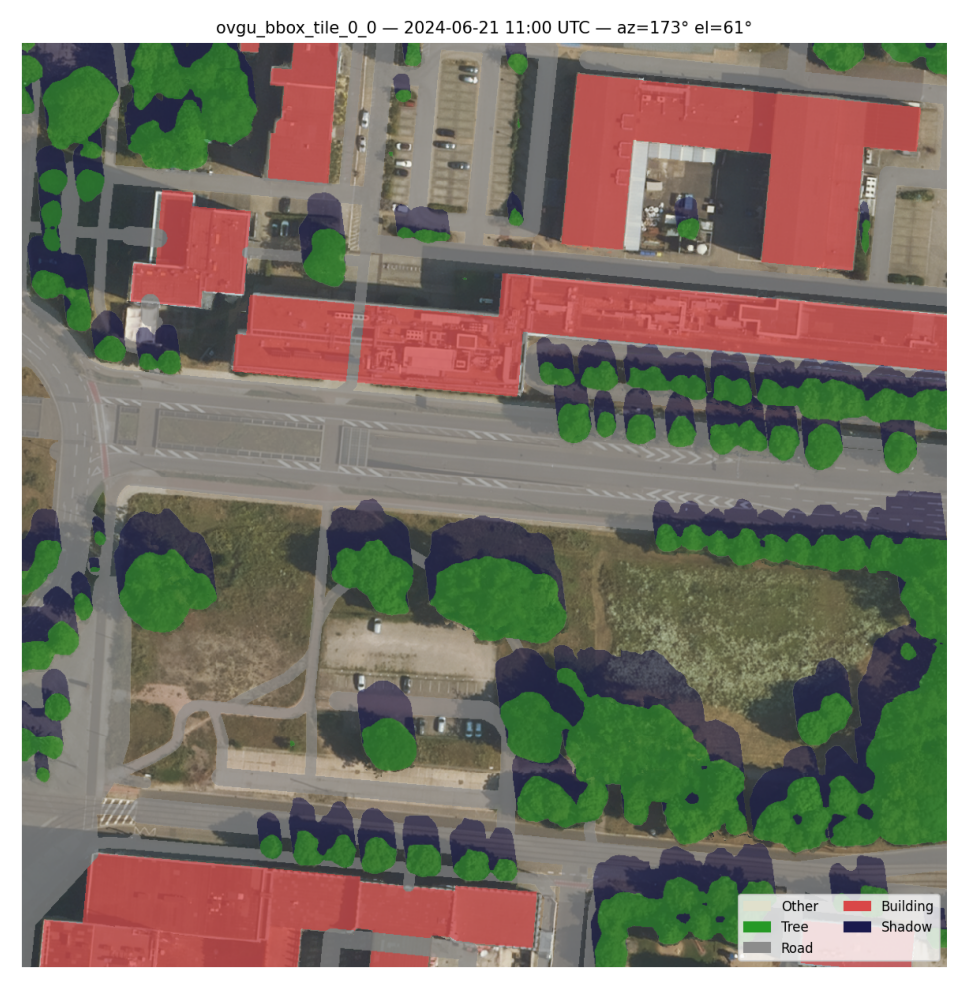

In [27]:
out_path = OUTPUT_DIR / "shadows" / f"{TILE_SIZE_M}m" / f"{stem}_{VEGETATION_MODEL}_shadow.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
save_shadow_overlay(
    img, seg_map, shadow_mask, out_path,
    title=f"{stem} — {DATETIME_UTC.strftime('%Y-%m-%d %H:%M UTC')} — az={azimuth:.0f}° el={elevation:.0f}°"
)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(plt.imread(out_path))
ax.axis("off")
plt.tight_layout()
plt.show()

## Sanity checks

In [29]:
# 1. Shadow must not overlap source tree pixels
assert not (shadow_mask & (seg_map == 1)).any(), "Shadow overlaps tree pixels!"
print("✓ No shadow on source tree pixels")

# 2. Per-cluster direction check: each individual shadow should be NORTH of its source
#    tree (negative row offset) for a sun at SSE (~173°).
#    Note: the GLOBAL shadow-vs-tree centroid comparison is misleading because
#    shadows from northern trees get clipped at the image edge, skewing aggregates.
import math
from src.shadow.casting import _shift_mask

pixel_size_check = _pixel_size_m(tile, seg_map.shape)
labeled_check, heights_check = estimate_tree_heights(seg_map == 1, pixel_size_check)
shadow_az_rad_check = math.radians((azimuth + 180) % 360)
elevation_rad_check = math.radians(elevation)

sampled_offsets = []
for k in list(heights_check.keys())[::20]:
    h_tree, crown_radius = heights_check[k]
    shadow_length = min(h_tree / math.tan(elevation_rad_check), 5 * crown_radius)
    dx = shadow_length * math.sin(shadow_az_rad_check) / pixel_size_check
    dy = -shadow_length * math.cos(shadow_az_rad_check) / pixel_size_check
    comp = labeled_check == k
    shifted = _shift_mask(comp, int(round(dy)), int(round(dx)))
    shd_r = np.where(shifted)[0]
    if len(shd_r):
        sampled_offsets.append(shd_r.mean() - np.where(comp)[0].mean())

assert all(o < 0 for o in sampled_offsets), f"Expected northward shadow, got: {sampled_offsets}"
print(f"✓ All sampled per-cluster shadows are north of source trees (mean offset {np.mean(sampled_offsets):.1f} px)")

# 3. Night datetime should produce no shadow
night = dt.datetime(2024, 6, 21, 22, 0, 0, tzinfo=dt.timezone.utc)
night_shadow = cast_tree_shadows(seg_map, tile, night)
assert not night_shadow.any(), "Night should produce no shadow!"
print("✓ No shadow at night")

print("\nAll sanity checks passed.")

✓ No shadow on source tree pixels
✓ All sampled per-cluster shadows are north of source trees (mean offset -37.8 px)
✓ No shadow at night

All sanity checks passed.


## Shadow length vs. sun elevation (diurnal cycle)

In [ ]:
print(f"{'Hour UTC':>8}  {'Elevation':>9}  {'Azimuth':>8}  {'Shadow %':>9}")
print("-" * 45)
for hour in range(4, 21, 2):
    when = DATETIME_UTC.replace(hour=hour)
    az, el = sun_position(lat, lon, when)
    shd = cast_tree_shadows(seg_map, tile, when)
    print(f"{hour:>8}  {el:>8.1f}°  {az:>7.1f}°  {shd.mean()*100:>8.1f}%")

Hour UTC  Elevation   Azimuth   Shadow %
---------------------------------------------
       4       7.7°     61.2°      13.6%
       6      25.1°     83.4°      14.5%
       8      43.2°    108.6°      13.2%
      10      57.9°    146.2°      12.9%
      12      60.1°    200.9°      11.9%
      14      47.6°    243.5°      13.6%
      16      29.8°    270.7°      12.6%
      18      11.9°    293.1°      11.7%
      20      -3.2°    316.2°       0.0%


## Batch: all tiles

In [ ]:
for t in tiles_for_area(AREAS[AREA_KEY], TILE_SIZE_M):
    s = f"{AREA_KEY}_tile_{t['ix']}_{t['iy']}"
    seg_p = OUTPUT_DIR / "segments" / f"{TILE_SIZE_M}m" / f"{s}_{VEGETATION_MODEL}_seg.npy"
    img_p = OUTPUT_DIR / AREA_KEY / f"{TILE_SIZE_M}m" / f"{s}.png"
    if not seg_p.exists():
        print(f"[skip] {seg_p.name}")
        continue
    seg = np.load(seg_p)
    im  = np.array(Image.open(img_p).convert("RGB"))
    shd = cast_tree_shadows(seg, t, DATETIME_UTC)
    out = OUTPUT_DIR / "shadows" / f"{TILE_SIZE_M}m" / f"{s}_{VEGETATION_MODEL}_shadow.png"
    out.parent.mkdir(parents=True, exist_ok=True)
    save_shadow_overlay(im, seg, shd, out, title=f"{s} — {DATETIME_UTC.strftime('%Y-%m-%d %H:%M UTC')}")
    print(f"{s}: shadow={shd.mean()*100:.1f}%")

ovgu_bbox_tile_0_0: shadow=11.7%
ovgu_bbox_tile_0_1: shadow=15.7%
ovgu_bbox_tile_1_0: shadow=12.0%
ovgu_bbox_tile_1_1: shadow=10.0%


In [ ]:
import geopandas as gpd
from shapely.geometry import box    

In [ ]:
trees = gpd.read_file("/Users/kumar/Desktop/Projects.nosync/HiWi1/urban-shadow-analysis/data/orthophotos/segments/ovgu_bbox_tile_3_3_tcd_segformer_trees.fgb")

In [ ]:
trees

,tree_id,height_m,crown_radius_m,crown_area_m2,vegetation_model,geometry
0,23,7.600076,5.428626,92.582657,tcd_segformer,"POLYGON ((681502.137 5780415.004, 681502.137 5..."
1,22,10.200970,7.286407,166.792601,tcd_segformer,"POLYGON ((681490.706 5780415.531, 681490.706 5..."
2,26,1.282567,0.916119,2.636658,tcd_segformer,"POLYGON ((681479.275 5780402.626, 681479.275 5..."
3,28,1.925793,1.375566,5.944466,tcd_segformer,"POLYGON ((681487.39 5780395.909, 681487.39 578..."
4,29,3.880596,2.771854,24.137407,tcd_segformer,"POLYGON ((681481.02 5780390.247, 681481.02 578..."
5,25,1.163343,0.830960,2.169251,tcd_segformer,"POLYGON ((681476.395 5780402.889, 681476.395 5..."
6,24,1.423486,1.016776,3.247884,tcd_segformer,"POLYGON ((681471.421 5780407.63, 681471.421 57..."
7,20,4.983140,3.559386,39.801554,tcd_segformer,"POLYGON ((681485.732 5780448.585, 681485.732 5..."
8,19,4.116220,2.940157,27.157579,tcd_segformer,"POLYGON ((681499.52 5780462.807, 681499.52 578..."
9,13,3.245818,2.318441,16.886597,tcd_segformer,"POLYGON ((681504.144 5780480.585, 681504.144 5..."


In [32]:
import geopandas as gpd

BAUMKATASTER_PATH = Path("../references/Baeume_SFM_2026.gpkg")
bk = gpd.read_file(BAUMKATASTER_PATH)  # already EPSG:25832

# Columns:
#   Gattung lang        — species (Latin + German name)
#   Baumhoehe           — total height (m)
#   Kronendurchmesser   — crown diameter (m)
#   Stammumfang         — trunk circumference (cm)
#   Pflanzjahr          — planting year
#   Objektart lang      — location type (Öffentliches Grün / AMT 66 / Spielplatz)

print(f"Total trees (Magdeburg): {len(bk):,}")
print(f"CRS: {bk.crs}")
bk[["Gattung lang", "Baumhoehe", "Kronendurchmesser", "Stammumfang", "Pflanzjahr"]].describe()

Total trees (Magdeburg): 85,302
CRS: EPSG:25832


,Baumhoehe,Kronendurchmesser,Stammumfang,Pflanzjahr
count,85302.000000,85302.000000,85302.000000,85302.000000
mean,12.132330,6.854219,115.711759,726.708635
std,6.828413,3.823997,83.834198,955.401080
min,0.000000,0.000000,0.000000,0.000000
25%,8.000000,4.000000,65.000000,0.000000
50%,11.000000,6.000000,100.000000,0.000000
75%,16.000000,9.000000,150.000000,1970.000000
max,810.000000,85.000000,6775.000000,2025.000000


In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from shapely.geometry import box

ovgu = AREAS["ovgu_bbox"]
bbox_utm = gpd.GeoDataFrame(
    geometry=[box(ovgu["west"], ovgu["south"], ovgu["east"], ovgu["north"])],
    crs="EPSG:4326",
).to_crs("EPSG:25832")

bk_ovgu = bk.clip(bbox_utm).copy()
bk_ovgu = bk_ovgu[bk_ovgu["Kronendurchmesser"] > 0].reset_index(drop=True)

print(f"Trees in OVGU bbox (with crown data): {len(bk_ovgu)}")
print(f"Crown diameter — mean: {bk_ovgu['Kronendurchmesser'].mean():.1f} m  "
      f"median: {bk_ovgu['Kronendurchmesser'].median():.1f} m  "
      f"max: {bk_ovgu['Kronendurchmesser'].max():.1f} m")

print("\n--- Species (OVGU) ---")
print(bk_ovgu["Gattung lang"].value_counts().head(15).to_string())

# Buffer each point by crown radius → actual circular footprint in map units
bk_crown = bk_ovgu.copy()
bk_crown["geometry"] = bk_crown.apply(
    lambda r: r.geometry.buffer(r["Kronendurchmesser"] / 2), axis=1
)

norm = mcolors.Normalize(vmin=bk_ovgu["Kronendurchmesser"].quantile(0.05),
                         vmax=bk_ovgu["Kronendurchmesser"].quantile(0.95))
cmap = cm.YlGn
colors = cmap(norm(bk_crown["Kronendurchmesser"].values))

fig, ax = plt.subplots(figsize=(10, 10))
bk_crown.plot(ax=ax, color=colors, edgecolor="darkgreen", linewidth=0.3, alpha=0.7)
bbox_utm.boundary.plot(ax=ax, color="red", linewidth=1.5, label="OVGU bbox")

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Crown diameter (m)", shrink=0.6)

ax.set_title(f"Baumkataster — OVGU area ({len(bk_crown)} trees, crown circles to scale)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
import math
import numpy as np
from src.config import ALLOMETRIC_A, ALLOMETRIC_B

# Fit ln(H) = A + B·ln(CPA) on Baumkataster (citywide, valid measurements only)
cal = bk[["Baumhoehe", "Kronendurchmesser"]].copy()
cal = cal[(cal["Baumhoehe"] > 1) & (cal["Kronendurchmesser"] > 0.5)]  # drop zeros/tiny
cal["CPA_m2"] = math.pi * (cal["Kronendurchmesser"] / 2) ** 2
cal["ln_H"]   = np.log(cal["Baumhoehe"])
cal["ln_CPA"] = np.log(cal["CPA_m2"])

# OLS: ln(H) = A + B·ln(CPA)
X = np.column_stack([np.ones(len(cal)), cal["ln_CPA"].values])
B_hat, resid, _, _ = np.linalg.lstsq(X, cal["ln_H"].values, rcond=None)
A_urban, B_urban = B_hat

r2 = 1 - np.sum((cal["ln_H"] - (A_urban + B_urban * cal["ln_CPA"])) ** 2) / \
         np.sum((cal["ln_H"] - cal["ln_H"].mean()) ** 2)

print("=== Baumkataster-calibrated allometric model (citywide) ===")
print(f"  H = exp({A_urban:.3f} + {B_urban:.3f} · ln(CPA))   R² = {r2:.3f}   n = {len(cal):,}")
print()
print("=== Current config (Schmucker forest-tree proxy) ===")
print(f"  H = exp({ALLOMETRIC_A:.3f} + {ALLOMETRIC_B:.3f} · ln(CPA))")
print()

# Compare predictions at representative crown areas
print(f"{'Crown D (m)':>12}  {'CPA (m²)':>10}  {'H_urban (m)':>12}  {'H_config (m)':>13}  {'Bk median H':>12}")
for cd in [4, 6, 8, 10, 12, 14]:
    cpa = math.pi * (cd / 2) ** 2
    h_urban = math.exp(A_urban + B_urban * math.log(cpa))
    h_config = math.exp(ALLOMETRIC_A + ALLOMETRIC_B * math.log(cpa))
    bk_med = bk[(bk["Kronendurchmesser"].between(cd - 0.5, cd + 0.5)) &
                (bk["Baumhoehe"] > 1)]["Baumhoehe"].median()
    print(f"{cd:>12}  {cpa:>10.1f}  {h_urban:>12.1f}  {h_config:>13.1f}  {bk_med:>12.1f}")

print()
print(f"Suggested update to src/config.py:")
print(f"  ALLOMETRIC_A = {A_urban:.3f}   # fitted on Magdeburg Baumkataster 2026 (n={len(cal):,})")
print(f"  ALLOMETRIC_B = {B_urban:.3f}   # power-law exponent on CPA (m²)")

=== Baumkataster-calibrated allometric model (citywide) ===
  H = exp(1.317 + 0.318 · ln(CPA))   R² = 0.531   n = 84,081

=== Current config (Schmucker forest-tree proxy) ===
  H = exp(1.317 + 0.318 · ln(CPA))

 Crown D (m)    CPA (m²)   H_urban (m)   H_config (m)   Bk median H
           4        12.6           8.4            8.3           8.0
           6        28.3          10.8           10.8          10.0
           8        50.3          13.0           13.0          13.0
          10        78.5          15.0           14.9          15.0
          12       113.1          16.8           16.8          18.0
          14       153.9          18.5           18.5          20.0

Suggested update to src/config.py:
  ALLOMETRIC_A = 1.317   # fitted on Magdeburg Baumkataster 2026 (n=84,081)
  ALLOMETRIC_B = 0.318   # power-law exponent on CPA (m²)


In [36]:
from pyproj import Transformer
from shapely.ops import unary_union

TILE_SIZE = 250       # change to 100 / 500 / 1000 to compare other sizes
VEGETATION_MODEL_R = "tcd_segformer"

_to_utm = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)
area = AREAS["ovgu_bbox"]
west_m, south_m = _to_utm.transform(area["west"], area["south"])
east_m, north_m = _to_utm.transform(area["east"], area["north"])
extent = [west_m, east_m, south_m, north_m]

full_img = np.array(Image.open(OUTPUT_DIR / "ovgu_bbox" / "ovgu_bbox_full.png").convert("RGB"))

trees_path  = OUTPUT_DIR / "segments" / f"{TILE_SIZE}m" / f"ovgu_bbox_{VEGETATION_MODEL_R}_trees_merged.fgb"
shadow_path = OUTPUT_DIR / "shadows"  / f"{TILE_SIZE}m" / f"ovgu_bbox_{VEGETATION_MODEL_R}_shadow_merged.fgb"
buildings_path = OUTPUT_DIR / "buildings_ovgu_bbox.fgb"

trees_raw   = gpd.read_file(trees_path)
shadow_raw  = gpd.read_file(shadow_path) if shadow_path.exists() else None
buildings   = gpd.read_file(buildings_path) if buildings_path.exists() else None

# --- Dissolve watershed split lines ---
# Buffer by half a pixel (~0.2 m) to close 1-pixel ridge gaps, union, then shrink back.
SNAP = 0.3   # metres — just above the pixel size (0.2 m)
merged_union  = unary_union(trees_raw.geometry.buffer(SNAP))
trees_clean   = gpd.GeoDataFrame(
    geometry=gpd.GeoSeries([merged_union], crs=trees_raw.crs).explode(index_parts=False),
    crs=trees_raw.crs,
).reset_index(drop=True)
trees_clean["geometry"] = trees_clean.geometry.buffer(-SNAP)   # shrink back

if shadow_raw is not None:
    shadow_union = unary_union(shadow_raw.geometry.buffer(SNAP))
    shadow_clean = gpd.GeoDataFrame(
        geometry=gpd.GeoSeries([shadow_union], crs=shadow_raw.crs).explode(index_parts=False),
        crs=shadow_raw.crs,
    ).reset_index(drop=True)
    shadow_clean["geometry"] = shadow_clean.geometry.buffer(-SNAP)
else:
    shadow_clean = None

print(f"Tree polygons  before: {len(trees_raw):>4}   after dissolve: {len(trees_clean)}")
if shadow_raw is not None:
    print(f"Shadow polygons before: {len(shadow_raw):>4}   after dissolve: {len(shadow_clean)}")

Tree polygons  before:  942   after dissolve: 835
Shadow polygons before: 3526   after dissolve: 1568


In [ ]:
merged_trees = gpd.read_file("/Users/kumar/Desktop/Projects.nosync/HiWi1/urban-shadow-analysis/data/orthophotos/segments/250m/ovgu_bbox_tcd_segformer_trees_merged.fgb")
merged_trees

,tree_id,height_m,crown_radius_m,crown_area_m2,vegetation_model,geometry
0,41,8.530228,2.069580,13.455953,tcd_segformer,"POLYGON ((681495.593 5779639.914, 681495.593 5..."
1,42,4.974540,0.886403,2.468381,tcd_segformer,"POLYGON ((681487.041 5779639.706, 681487.041 5..."
2,40,17.972378,6.679715,140.173461,tcd_segformer,"POLYGON ((681403.968 5779652.206, 681403.968 5..."
3,39,11.675749,3.390224,36.108264,tcd_segformer,"POLYGON ((681400.129 5779670.748, 681400.129 5..."
4,38,12.487390,3.768077,44.605611,tcd_segformer,"POLYGON ((681415.661 5779674.081, 681415.661 5..."
...,...,...,...,...,...,...
937,52,18.776227,7.155443,160.850694,tcd_segformer,"POLYGON ((680747.629 5779703.456, 680747.629 5..."
938,57,11.071960,3.118675,30.555556,tcd_segformer,"POLYGON ((680717.212 5779671.998, 680717.212 5..."
939,58,14.392077,4.710387,69.704861,tcd_segformer,"POLYGON ((680745.337 5779671.373, 680745.337 5..."
940,56,16.490664,5.834507,106.944444,tcd_segformer,"POLYGON ((680725.337 5779673.039, 680725.337 5..."
